In [ ]:
# Download example datasets

import pooch

file_path_2d = pooch.retrieve(url="https://zenodo.org/records/15278227/files/2layer_128.jld2", 
                           known_hash="a04abc602ca3bbc4ff9a868a96848b6815a17f697202fb12e3ff40762de92ec6")

file_path_3d = pooch.retrieve(url="https://zenodo.org/records/15278227/files/langmuir_fields.nc", 
                           known_hash="d32f5f4c02791ddc584abecc572a5f06a948638ba4e45c4d6952a0723c3c1e40")

In [ ]:
### Load 2D data 

import h5py
import xarray as xr
import numpy as np

f = h5py.File(file_path_2d, 'r')
grid = f['grid']
snapshots = f['snapshots']

x = grid['x'][()]
y = grid['y'][()]

# Grab the top layer of u and v for all time snapshots
u = np.array([snapshots['u'][key][0] for key in snapshots['u'].keys()])
v = np.array([snapshots['v'][key][0] for key in snapshots['v'].keys()])

ds_2d = xr.Dataset(
    data_vars={
        "u": (("time", "y", "x"), u),
        "v": (("time", "y", "x"), v),
    },
    coords={
        "time": np.arange(u.shape[0]),
        "y": y,
        "x": x,
    },
)


# Load 3D data
ds_3d = xr.load_dataset(file_path_3d)

In [ ]:
def compute_LLL(
    ds,
    shiftby,
    U_vec,
    X_vec,
    time_dim="time",
    periodic=False,
):
    """
    Compute the third-order structure function LLL for a given dataset and specified 
    shifts. Dataset should contain the velocity components specified in U_vec and the 
    spatial coordinates specified in X_vec, but can have any dimensionality. The 
    function will compute the LLL structure function for each direction specified in 
    X_vec, using the corresponding velocity component in U_vec. 
    For example, if U_vec = ['u', 'v'] and X_vec = ['x', 'y'], the function will 
    compute the LLL structure function for the u velocity component in the x direction 
    and the v velocity component in the y direction, a total of 2 structure functions.

    Parameters
    ----------
    ...
    shiftby : int or list of int
        The amount by which to shift the fields when computing the structure function.
        If a list is provided, the function computes the structure function for each
        shift value.
    U_vec : list of str
        A list of variable names corresponding to the velocity components in the 
        dataset.
    X_vec : list of str
        A list of variable names corresponding to the spatial coordinates in the 
        dataset.
    periodic : bool, tuple, or list, optional
        Whether to apply periodic boundary conditions when shifting the fields. If a 
        boolean is provided, it will be applied to all directions. If a tuple or list 
        is provided, it should contain n boolean values specifying whether to apply 
        periodic boundary conditions for the n directions. For example, for a 2D 
        dataset, periodic could be (True, False) to apply periodic boundary conditions 
        in the x direction but not in the y direction. Defaults to False.
    ...

    Returns
    -------
        xr.Dataset:
            A dataset containing the computed LLL structure functions for each 
            specified direction, along with coordinates for the shift amounts.
    ...

    """    
    ds_LLL = xr.Dataset()
    shift_values = np.atleast_1d(shiftby)

    for i, (U_i, X_i) in enumerate(zip(U_vec, X_vec, strict=False)):
        
        periodic_i = periodic if isinstance(periodic, bool) else periodic[i]
        avg_dim = [d for d in ds[U_i].dims if d != time_dim] # Average over all spatial dimensions except time

        # The shifting list comp is doing all the heavy lifting in terms of iteration, 
        # so it would also be a bottle neck. Supplying a pre-chunked dataset should help
        # at this point, but there might be better options. 
        sf_results = [
            (
                ds[U_i].roll({X_i: int(shift_i)}, roll_coords=False)
                if periodic_i
                else ds[U_i].shift({X_i: int(shift_i)})
            )
            for shift_i in shift_values
        ]

        # Just reformatting the results of the list comp into a dataset with a new 
        # shiftby dimension. Since we call a mean here, this might take longer if 
        # the initial dataset is not already chunked.
        ds_LLL[f"SF_{U_i}{U_i}{U_i}"] = xr.concat(
            [
                ((ds[U_i] - shifted) ** 3).mean(dim=avg_dim).expand_dims(
                    shiftby=[shift_i]
                )
                for shifted, shift_i in zip(sf_results, shift_values, strict=False)
            ],
            dim="shiftby",
        ).assign_coords(shiftby=shift_values)

    return ds_LLL

In [56]:
ds_LLL_2d = compute_LLL(
    ds_2d.chunk("auto"),
    shiftby=range(len(x) // 2),
    U_vec=["u", "v"],
    X_vec=["x", "y"],
    time_dim="time",
    periodic=True,
    )

ds_LLL_3d = compute_LLL(
    ds_3d.chunk("auto"),
    shiftby=range(len(ds_3d['xC']) // 2),
    U_vec=["u", "v", "w"],
    X_vec=["xF", "yF", "zF"],
    time_dim="time",
    periodic=True,
    )


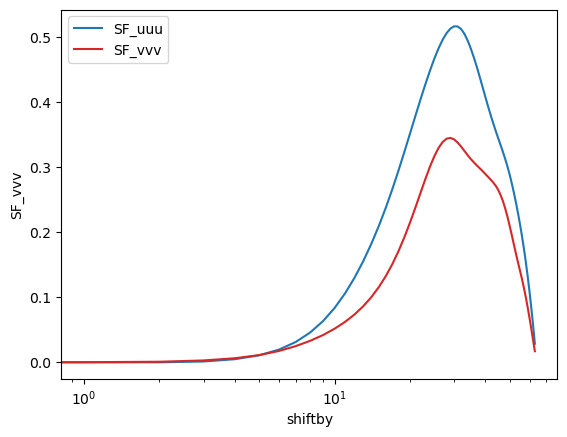

In [62]:
import matplotlib.pyplot as plt

ds_LLL_2d.SF_uuu.mean(dim="time").plot(x="shiftby", label="SF_uuu", color="C0")
ds_LLL_2d.SF_vvv.mean(dim="time").plot(x="shiftby", label="SF_vvv", color="C3")
plt.semilogx()
plt.legend()
plt.show()

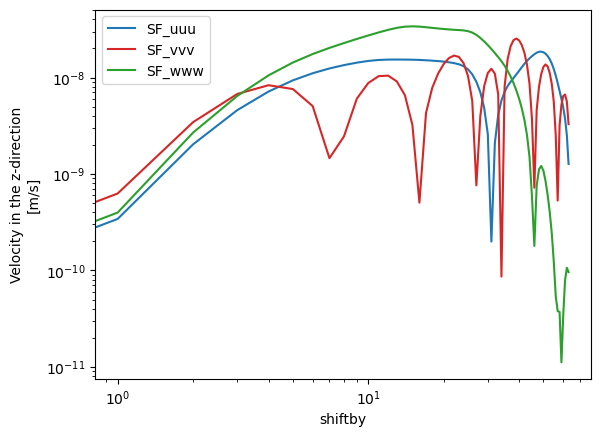

In [60]:

np.abs(ds_LLL_3d.SF_uuu.mean(dim="time")).plot(x="shiftby", label="SF_uuu", color="C0")
np.abs(ds_LLL_3d.SF_vvv.mean(dim="time")).plot(x="shiftby", label="SF_vvv", color="C3")
np.abs(ds_LLL_3d.SF_www.mean(dim="time")).plot(x="shiftby", label="SF_www", color="C2")

plt.loglog()
plt.legend()
plt.show()